# 浅拷贝
1. 定义：浅拷贝会创建一个**新的外层容器对象**，但容器内的所有元素，依然是原对象元素的引用（只拷贝最外层，嵌套的内层对象不拷贝，共享内存地址）。
2. 常见实现方式
   1. 序列类型切片操作：obj[:]
   2. 容器工厂函数：list(obj) / dict(obj) / set(obj)
   3. copy模块标准方法：copy.copy(obj)
3. 案例1:单层无嵌套的可变对象

In [2]:
import copy

# 原对象：单层列表，元素均为不可变的int类型
origin = [1, 2, 3]

# 三种浅拷贝方式
copy1 = origin[:]
copy2 = list(origin)
copy3 = copy.copy(origin)

# 修改拷贝对象的外层元素
copy1[0] = 999

# 结果：原对象不受影响
print("原对象:", origin)    # 原对象: [1, 2, 3]
print("浅拷贝1:", copy1)    # 浅拷贝1: [999, 2, 3]

print(id(origin))
print(id(copy1))
print(id(copy2))
print(id(copy3))

原对象: [1, 2, 3]
浅拷贝1: [999, 2, 3]
4499699840
4499699648
4499989184
4499699776


**解释**：单层列表的元素是不可变类型，修改拷贝对象的元素，本质上是让该位置指向了新的对象，不会影响原对象。
4. 案例2:带嵌套可变对象的浅拷贝（核心差异点）

In [3]:
import copy

# 原对象：包含嵌套的可变子列表
origin = [1, 2, [3, 4]]

# 浅拷贝
shallow_copy = copy.copy(origin)

# 1. 修改外层不可变元素
shallow_copy[0] = 999
print("修改外层后原对象:", origin)       # 修改外层后原对象: [1, 2, [3, 4]]
print("修改外层后浅拷贝:", shallow_copy) # 修改外层后浅拷贝: [999, 2, [3, 4]]

# 2. 修改内层嵌套的可变对象
shallow_copy[2][0] = 666
print("修改内层后原对象:", origin)       # 修改内层后原对象: [1, 2, [666, 4]]
print("修改内层后浅拷贝:", shallow_copy) # 修改内层后浅拷贝: [999, 2, [666, 4]]

修改外层后原对象: [1, 2, [3, 4]]
修改外层后浅拷贝: [999, 2, [3, 4]]
修改内层后原对象: [1, 2, [666, 4]]
修改内层后浅拷贝: [999, 2, [666, 4]]


**解释**：浅拷贝只复制了最外层的列表，内层的[3,4]子列表，依然和原对象共享同一个内存引用。因此修改内层可变对象的内容，原对象会同步被修改。

# 二、深拷贝
1. 定义：深拷贝会递归拷贝原对象的所有层级元素，创建一个完全独立的新对象。新对象和原对象的所有内存地址都不共享，无论修改外层还是内层元素，都不会互相影响。
2. 唯一标准实现方式：
    - copy模块的递归拷贝方式：copy.deepcopy(obj)
3. 案例1:带嵌套可变对象的深拷贝

In [4]:
import copy

# 原对象：包含嵌套的可变子列表
origin = [1, 2, [3, 4]]

# 深拷贝
deep_copy = copy.deepcopy(origin)

# 1. 修改外层元素
deep_copy[0] = 999
print("修改外层后原对象:", origin)     # 修改外层后原对象: [1, 2, [3, 4]]
print("修改外层后深拷贝:", deep_copy)  # 修改外层后深拷贝: [999, 2, [3, 4]]

# 2. 修改内层嵌套的可变对象
deep_copy[2][0] = 666
print("修改内层后原对象:", origin)     # 修改内层后原对象: [1, 2, [3, 4]]
print("修改内层后深拷贝:", deep_copy)  # 修改内层后深拷贝: [999, 2, [666, 4]]

修改外层后原对象: [1, 2, [3, 4]]
修改外层后深拷贝: [999, 2, [3, 4]]
修改内层后原对象: [1, 2, [3, 4]]
修改内层后深拷贝: [999, 2, [666, 4]]


**解释**：深拷贝递归复制了所有层级的对象，内层的子列表也被重新创建了一份独立的内存空间，因此无论修改哪一层，原对象都完全不受影响。

# 三、避坑
1. 不可变对象的拷贝特性
    - 对于完全由不可变元素组成的不可变对象，Python为了节省内存，浅拷贝和深拷贝都不会创建新对象，只会返回原对象的引用。
    - 只有当不可变对象内部包含可变子元素时，深拷贝才会递归拷贝内部的可变元素。

In [5]:
import copy

# 纯不可变元素的元组
a = (1, 2, 3)
b = copy.copy(a)
c = copy.deepcopy(a)
print(a is b)  # True，同一个对象
print(a is c)  # True，同一个对象

# 包含可变子元素的元组
d = (1, 2, [3,4])
e = copy.copy(d)
f = copy.deepcopy(d)
print(d[2] is e[2])  # True，内层列表共享引用
print(d[2] is f[2])  # False，内层列表被独立拷贝

True
True
True
False


2. 循环引起的处理
    - deepcopy会自动处理循环引用的对象（比如对象内部引用了自己），避免递归栈溢出；而浅拷贝仅传递引用，不做特殊处理。

In [6]:
import copy
a = []
a.append(a)  # 循环引用：列表自己包含自己
b = copy.deepcopy(a)
print(a is b)  # False，成功创建独立新对象，无栈溢出

False


# 比较
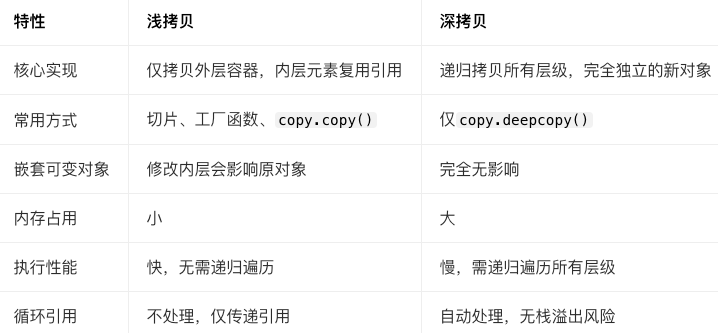